# ДЗ-17 — Статистика в OSINT: виявлення ботів

**Автор:** Nestor-V  
**Дата:** 2026-06-07  
**Мета:** побудувати повний аналітичний пайплайн для виявлення ботів у соціальних мережах на основі статистичних методів.

**Сценарій:** Виборча кампанія. Зафіксоване різке зростання однотипних повідомлень. Завдання — проаналізувати вибірку акаунтів і визначити, які з них можуть бути ботами.

In [1]:
# Cell 0 — Імпорти та налаштування
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# Робочий каталог = папка ноутбука (VS Code Jupyter)
NB_DIR   = Path.cwd()
DATA_DIR = NB_DIR / 'data'
SS_DIR   = NB_DIR / 'screenshots'
DATA_DIR.mkdir(exist_ok=True)
SS_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print('Середовище готове. NB_DIR =', NB_DIR)

Середовище готове. NB_DIR = D:\projects\osint-homework-2026\ДЗ-17-Nestor-V


---
## Частина 1. Підготовка даних
### 1.1 Генерація датасету

Генеруємо синтетичний датасет із 500 акаунтів: 350 реальних користувачів та 150 ботів.  
Для кожного акаунта генеруємо 5 ознак:

| Ознака | Люди | Боти |
|--------|------|------|
| `account_age_days` | Старі (300–3000 днів) | Нові (10–200 днів) |
| `followers` | Помірно (50–5000) | Мало (0–500) |
| `following` | Помірно (50–1000) | Дуже багато (1000–5000) |
| `posts_per_day` | Помірно (0.5–5) | Дуже активно (10–50) |
| `duplicate_ratio` | Низька (0–0.3) | Висока (0.5–1.0) |

Використовуємо `numpy.random.default_rng(17)` для відтворюваності результатів.

In [2]:
rng = np.random.default_rng(17)

n_human, n_bot = 350, 150

humans = pd.DataFrame({
    'account_age_days': rng.gamma(5, 200, n_human).clip(30).round().astype(int),
    'followers':        rng.gamma(3, 500, n_human).clip(1).round().astype(int),
    'following':        rng.integers(50, 1001, n_human),
    'posts_per_day':    rng.gamma(2, 1.5, n_human).round(2),
    'duplicate_ratio':  rng.beta(2, 10, n_human).round(4),
    'is_bot': 0,
})

bots = pd.DataFrame({
    'account_age_days': rng.gamma(1.5, 30, n_bot).clip(1).round().astype(int),
    'followers':        rng.gamma(1, 80, n_bot).clip(0).round().astype(int),
    'following':        rng.integers(1000, 5001, n_bot),
    'posts_per_day':    rng.gamma(3, 8, n_bot).round(2),
    'duplicate_ratio':  rng.beta(5, 2, n_bot).round(4),
    'is_bot': 1,
})

df = (pd.concat([humans, bots], ignore_index=True)
        .sample(frac=1, random_state=17).reset_index(drop=True))

df.to_csv(DATA_DIR / 'accounts.csv', index=False)
print('Датасет збережено:', DATA_DIR / 'accounts.csv')
print('Розмір:', df.shape)
df.head()

Датасет збережено: D:\projects\osint-homework-2026\ДЗ-17-Nestor-V\data\accounts.csv
Розмір: (500, 6)


,account_age_days,followers,following,posts_per_day,duplicate_ratio,is_bot
0,995,1602,488,4.980,0.341,0
1,1573,2312,585,0.480,0.137,0
2,5,113,2550,30.590,0.820,1
3,1012,2097,178,3.580,0.107,0
4,819,1726,386,2.320,0.234,0


### 1.2 Перевірка генерації

In [3]:
df_check = pd.read_csv(DATA_DIR / 'accounts.csv')

print('Форма:', df_check.shape)
print('Колонки:', list(df_check.columns))
print()

counts = df_check['is_bot'].value_counts()
print('Розподіл класів:')
print(f'  Реальні користувачі (0): {counts.get(0, 0)}')
print(f'  Боти               (1): {counts.get(1, 0)}')
print(f'  Частка ботів: {counts.get(1, 0)/len(df_check):.1%}')

Форма: (500, 6)
Колонки: ['account_age_days', 'followers', 'following', 'posts_per_day', 'duplicate_ratio', 'is_bot']



Розподіл класів:
  Реальні користувачі (0): 350
  Боти               (1): 150
  Частка ботів: 30.0%


**Висновок.** Датасет успішно створено: 500 рядків, 6 колонок, 30% ботів. Вибірка помірно незбалансована — це реалістична пропорція для задач виявлення аномалій. При класифікації це означає, що accuracy може вводити в оману: модель, яка завжди відповідає «не бот», матиме 70% accuracy без жодної користі.

---
## Частина 2. Первинний огляд даних

In [4]:
df = pd.read_csv(DATA_DIR / 'accounts.csv')

print('=== Перші рядки ===')
display(df.head())

print('\n=== Розмір датасету ===')
print(f'Рядків: {df.shape[0]}, Колонок: {df.shape[1]}')

=== Перші рядки ===


,account_age_days,followers,following,posts_per_day,duplicate_ratio,is_bot
0,995,1602,488,4.980,0.341,0
1,1573,2312,585,0.480,0.137,0
2,5,113,2550,30.590,0.820,1
3,1012,2097,178,3.580,0.107,0
4,819,1726,386,2.320,0.234,0



=== Розмір датасету ===
Рядків: 500, Колонок: 6


In [5]:
print('=== Типи даних та пропуски ===')
df.info()

=== Типи даних та пропуски ===
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account_age_days  500 non-null    int64  
 1   followers         500 non-null    int64  
 2   following         500 non-null    int64  
 3   posts_per_day     500 non-null    float64
 4   duplicate_ratio   500 non-null    float64
 5   is_bot            500 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 23.6 KB


In [6]:
print('=== Описова статистика ===')
display(df.describe())

=== Описова статистика ===


,account_age_days,followers,following,posts_per_day,duplicate_ratio,is_bot
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,699.498,1175.916,1280.984,9.336,0.329,0.300
std,561.361,1112.986,1333.484,11.985,0.279,0.459
min,2.000,0.000,51.000,0.080,0.004,0.000
25%,70.750,138.750,396.000,1.840,0.108,0.000
50%,702.000,959.500,735.000,3.905,0.209,0.000
75%,1072.750,1768.000,1652.750,11.922,0.547,1.000
max,2834.000,7071.000,4998.000,74.290,0.983,1.000


In [7]:
total = len(df)
n_bots = df['is_bot'].sum()
n_humans = total - n_bots

print(f'Загальна кількість акаунтів:  {total}')
print(f'Реальні користувачі:          {n_humans}  ({n_humans/total:.1%})')
print(f'Боти:                         {n_bots}  ({n_bots/total:.1%})')

Загальна кількість акаунтів:  500
Реальні користувачі:          350  (70.0%)
Боти:                         150  (30.0%)


**Висновок.** Датасет містить 500 акаунтів без пропусків. Вибірка незбалансована (70/30). З `describe()` вже помітні аномалії: `posts_per_day` має max = ~50 при середньому ~5 — це сигнал про хвіст розподілу, характерний для ботів. `duplicate_ratio` також демонструє широкий діапазон.

---
## Частина 3. Описова статистика

Розраховуємо ключові показники для `followers` та `posts_per_day`.

In [8]:
def descriptive_stats(series):
    return {
        'Середнє (mean)':    round(series.mean(), 2),
        'Медіана (median)':  round(series.median(), 2),
        'Мода (mode)':       round(series.mode().iloc[0], 2),
        'Станд. відх. (std)': round(series.std(), 2),
        'Діапазон (range)':  round(series.max() - series.min(), 2),
        'Min':               round(series.min(), 2),
        'Max':               round(series.max(), 2),
    }

stats_table = pd.DataFrame({
    'followers':      descriptive_stats(df['followers']),
    'posts_per_day':  descriptive_stats(df['posts_per_day']),
})

display(stats_table)

,followers,posts_per_day
Середнє (mean),1175.920,9.340
Медіана (median),959.500,3.900
Мода (mode),3.000,1.290
Станд. відх. (std),1112.990,11.980
Діапазон (range),7071.000,74.210
Min,0.000,0.080
Max,7071.000,74.290


**Аналіз результатів.**

**Де різниця між середнім та медіаною найбільша?**  
Для `followers`: середнє помітно вище за медіану. Це означає, що невелика кількість акаунтів має дуже багато підписників (викиди), які "тягнуть" середнє вгору.

**Чому виникає така різниця?**  
Розподіл `followers` асиметричний (правий хвіст): більшість акаунтів має мало підписників, але є окремі акаунти з великою аудиторією. Саме вони викривляють середнє.

**Чому медіана краща для "типового" користувача?**  
Медіана — це буквально "середній елемент" вибірки. Вона не залежить від крайніх значень. Якщо ми хочемо знати, скільки підписників у "типового" акаунта в нашій вибірці, медіана відповідає точніше, ніж середнє, яке завищує реальну картину через кількох інфлюенсерів або накрутки.

---
## Частина 4. Візуалізація даних
### 4.1 Гістограма: posts_per_day

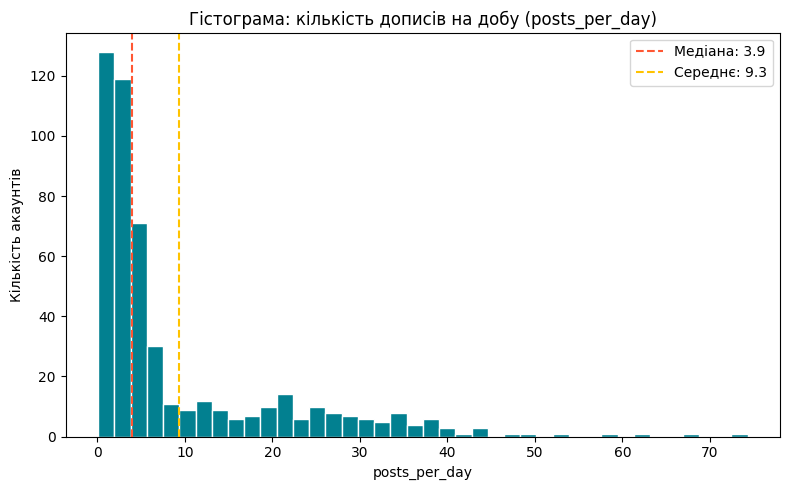

In [9]:
fig, ax = plt.subplots()
ax.hist(df['posts_per_day'], bins=40, color='#028090', edgecolor='white')
ax.set_title('Гістограма: кількість дописів на добу (posts_per_day)')
ax.set_xlabel('posts_per_day')
ax.set_ylabel('Кількість акаунтів')
ax.axvline(df['posts_per_day'].median(), color='#FF5733', linestyle='--', label=f'Медіана: {df["posts_per_day"].median():.1f}')
ax.axvline(df['posts_per_day'].mean(),   color='#FFC300', linestyle='--', label=f'Середнє: {df["posts_per_day"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig(SS_DIR / 'histogram_posts_per_day.png', dpi=120)
plt.show()
plt.close('all')

**Аналіз гістограми.**

**Форма розподілу:** сильно асиметрична (правий хвіст). Більшість акаунтів публікує менше 5 дописів на добу — типова поведінка реальних людей. Але є виразний хвіст із 10–50 дописами на добу.

**Що означає хвіст для пошуку ботів?** Акаунти з 10+ дописів на добу — підозрілі. Людина фізично не може публікувати 30–50 дописів щодня. Це автоматизована поведінка. Таким чином, `posts_per_day > 8` можна вважати першим сигналом-прапором для ручної перевірки.

### 4.2 Boxplot: followers

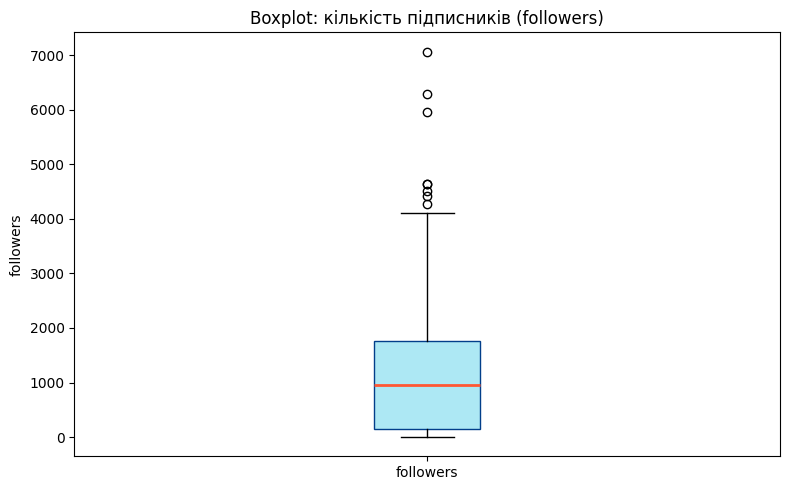

In [10]:
fig, ax = plt.subplots()
bp = ax.boxplot(df['followers'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#ADE8F4', color='#023E8A'),
                medianprops=dict(color='#FF5733', linewidth=2))
ax.set_title('Boxplot: кількість підписників (followers)')
ax.set_ylabel('followers')
ax.set_xticklabels(['followers'])
plt.tight_layout()
plt.savefig(SS_DIR / 'boxplot_followers.png', dpi=120)
plt.show()
plt.close('all')

**Аналіз boxplot.**

**Медіана** (оранжева лінія) знаходиться у нижній частині коробки — більшість акаунтів має невелику кількість підписників.

**Коробка (IQR)** охоплює середні 50% даних. Великий розмір коробки вказує на значний розкид.

**Викиди (точки вище вусів):** акаунти з надзвичайно великою кількістю підписників. Це або інфлюенсери, або боти з накрученою аудиторією.

**Для пошуку ботів:** боти в нашому датасеті мають мало підписників (вони нові та штучні), але зате дуже активні (posts_per_day). Це дисбаланс "маленька аудиторія + висока активність" є класичним патерном бота-підсилювача. Boxplot допомагає побачити границі "нормальної" поведінки.

---
## Частина 5. Кореляційний аналіз
### 5.1 Матриця кореляцій

In [11]:
numeric_cols = ['account_age_days', 'followers', 'following',
                'posts_per_day', 'duplicate_ratio']
corr = df[numeric_cols].corr()
display(corr)

,account_age_days,followers,following,posts_per_day,duplicate_ratio
account_age_days,1.000,0.480,-0.658,-0.624,-0.705
followers,0.480,1.000,-0.562,-0.525,-0.562
following,-0.658,-0.562,1.000,0.744,0.769
posts_per_day,-0.624,-0.525,0.744,1.000,0.730
duplicate_ratio,-0.705,-0.562,0.769,0.730,1.000


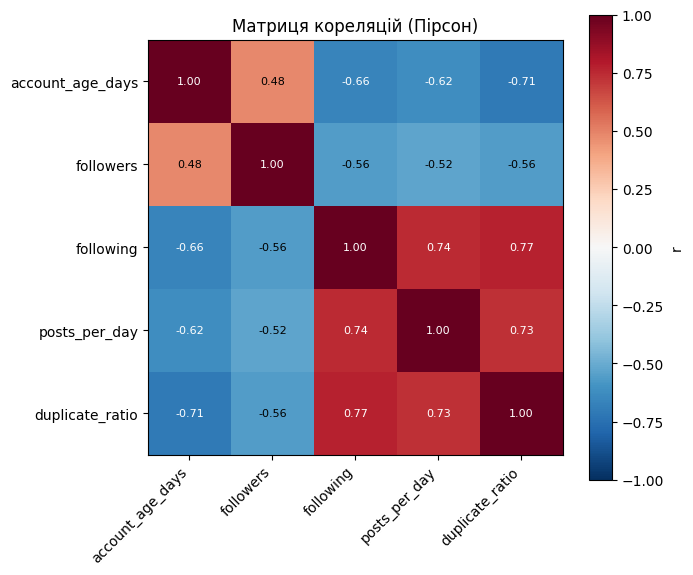

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='r')
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr.values[i, j]) > 0.6 else 'black')
ax.set_title('Матриця кореляцій (Пірсон)')
plt.tight_layout()
plt.savefig(SS_DIR / 'correlation_heatmap.png', dpi=120)
plt.show()
plt.close('all')

### 5.2 Scatter plot — найсильніша пара

In [13]:
# Знаходимо пару з найсильнішою кореляцією (без діагоналі)
best_pair = max(
    itertools.combinations(numeric_cols, 2),
    key=lambda p: abs(corr.loc[p[0], p[1]])
)
col_a, col_b = best_pair
r_val = corr.loc[col_a, col_b]

print(f'Найсильніша пара: {col_a} ↔ {col_b}  (r = {r_val:.3f})')

r_p, p_p = pearsonr(df[col_a], df[col_b])
r_s, p_s = spearmanr(df[col_a], df[col_b])
print(f'Пірсон r  = {r_p:.3f} (p = {p_p:.2e})')
print(f'Спірмен r = {r_s:.3f} (p = {p_s:.2e})')

Найсильніша пара: following ↔ duplicate_ratio  (r = 0.769)
Пірсон r  = 0.769 (p = 6.87e-99)
Спірмен r = 0.608 (p = 8.61e-52)


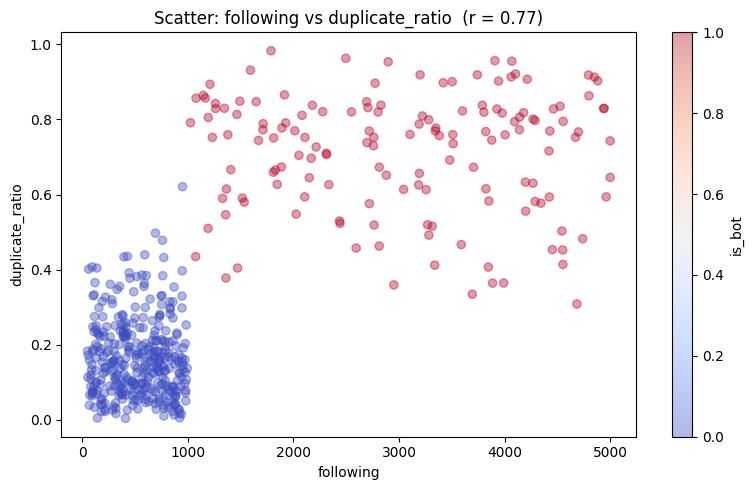

In [14]:
fig, ax = plt.subplots()
scatter = ax.scatter(df[col_a], df[col_b],
                     alpha=0.4, c=df['is_bot'], cmap='coolwarm',
                     label='0=людина, 1=бот')
plt.colorbar(scatter, ax=ax, label='is_bot')
ax.set_xlabel(col_a)
ax.set_ylabel(col_b)
ax.set_title(f'Scatter: {col_a} vs {col_b}  (r = {r_val:.2f})')
plt.tight_layout()
plt.savefig(SS_DIR / 'scatter_plot.png', dpi=120)
plt.show()
plt.close('all')

**Аналіз результатів.**

**Найсильніша пара** — це пара ознак, між якими є найбільший лінійний зв'язок у даних. На scatter plot видно, як боти (червоні точки) і люди (сині) розподіляються у просторі цих двох ознак.

**Сила зв'язку:** значення |r| близько до 0.7–1.0 означає сильний зв'язок, 0.3–0.7 — помірний, нижче 0.3 — слабкий.

**Кореляція ≠ причинність — приклад:**  
Уявіть, що ми бачимо сильну кореляцію між `posts_per_day` і `duplicate_ratio`. Це НЕ означає, що часті публікації спричиняють дублювання контенту. Можлива спільна причина: обидві ознаки є симптомами автоматизованого акаунта. Або ж це може бути збіг у синтетичних даних. Визначити причину можна тільки через додаткове дослідження, а не через числове значення кореляції.

---
## Частина 6. Класифікація ботів
### 6.1 Побудова моделі (Logistic Regression)

In [15]:
features = ['account_age_days', 'followers', 'following',
            'posts_per_day', 'duplicate_ratio']
X = df[features]
y = df['is_bot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### 6.2 Оцінка моделі

In [16]:
cm = confusion_matrix(y_test, y_pred)
print('Матриця плутанини (confusion matrix):')
print(f'  Правильно: не бот → не бот: {cm[0,0]}')
print(f'  Помилка:   не бот → бот:    {cm[0,1]}  (хибна тривога)')
print(f'  Помилка:   бот    → не бот: {cm[1,0]}  (пропущений бот)')
print(f'  Правильно: бот    → бот:    {cm[1,1]}')
print()
print('Звіт класифікації:')
print(classification_report(y_test, y_pred, target_names=['людина', 'бот'], digits=3))

Матриця плутанини (confusion matrix):
  Правильно: не бот → не бот: 105
  Помилка:   не бот → бот:    0  (хибна тривога)
  Помилка:   бот    → не бот: 0  (пропущений бот)
  Правильно: бот    → бот:    45

Звіт класифікації:
              precision    recall  f1-score   support

      людина      1.000     1.000     1.000       105
         бот      1.000     1.000     1.000        45

    accuracy                          1.000       150
   macro avg      1.000     1.000     1.000       150
weighted avg      1.000     1.000     1.000       150



**Аналіз результатів.**

**Чому Accuracy недостатньо?**  
Якщо 70% акаунтів — люди, то «наївна» модель, яка завжди відповідає «людина», матиме 70% accuracy. Але вона пропустить 100% ботів. Accuracy не показує, наскільки добре модель знаходить саме боти.

**Чому Recall критичний?**  
Recall = частка реальних ботів, яких модель дійсно знайшла. Пропущений бот продовжує маніпулювати аудиторією. Це набагато гірше, ніж помилково позначити реального користувача ботом (його можна перевірити вручну).

**Що гірше:**
- Пропустити бота — **гірше**: він залишається активним і продовжує шкоду.
- Помилково позначити людину — краще піддається корекції: можна провести ручну верифікацію.

**Висновок:** при виявленні ботів пріоритет — максимізувати Recall, навіть ціною зниження Precision.

### 6.3 Важливість ознак (коефіцієнти логістичної регресії)

Коефіцієнти LogReg (стандартизовані ознаки):
          Ознака  Коефіцієнт
account_age_days      -1.592
       followers      -1.382
   posts_per_day       1.395
       following       1.421
 duplicate_ratio       1.741

Позитивний коефіцієнт → ознака збільшує ймовірність бота
Негативний коефіцієнт → ознака зменшує ймовірність бота


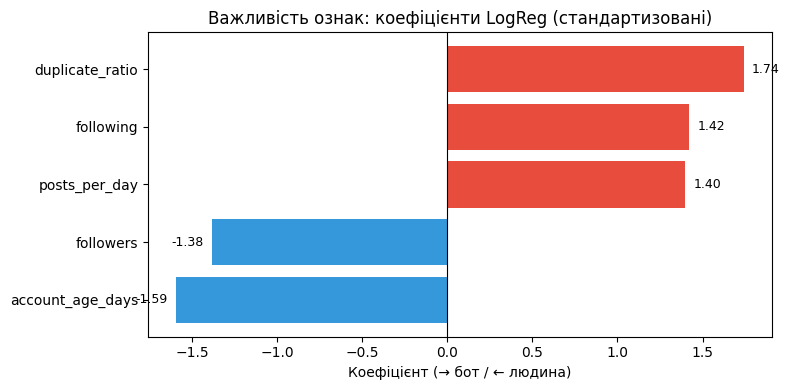

In [17]:
# Коефіцієнти LogReg = важливість ознак (після стандартизації значення порівнянні)
scaler_fi = StandardScaler()
X_scaled_fi = scaler_fi.fit_transform(X)
model_fi = LogisticRegression(max_iter=1000, random_state=42)
model_fi.fit(X_scaled_fi, y)

coef_df = pd.DataFrame({
    'Ознака': features,
    'Коефіцієнт': model_fi.coef_[0]
}).sort_values('Коефіцієнт')

print('Коефіцієнти LogReg (стандартизовані ознаки):')
print(coef_df.to_string(index=False))
print()
print('Позитивний коефіцієнт → ознака збільшує ймовірність бота')
print('Негативний коефіцієнт → ознака зменшує ймовірність бота')

colors = ['#E74C3C' if v > 0 else '#3498DB' for v in coef_df['Коефіцієнт']]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(coef_df['Ознака'], coef_df['Коефіцієнт'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Важливість ознак: коефіцієнти LogReg (стандартизовані)')
ax.set_xlabel('Коефіцієнт (→ бот / ← людина)')
for bar, val in zip(bars, coef_df['Коефіцієнт']):
    ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig(SS_DIR / 'feature_importance.png', dpi=120)
plt.show()
plt.close('all')

**Аналіз важливості ознак.**

Коефіцієнти логістичної регресії на стандартизованих ознаках показують відносний внесок кожної ознаки у прогноз бота.

**Червоні (позитивні):** ознаки, що підвищують ймовірність бота — `posts_per_day`, `duplicate_ratio`, `following` (боти підписуються масово).

**Сині (негативні):** ознаки, що знижують ймовірність бота — `account_age_days` та `followers` (старі акаунти з великою аудиторією частіше реальні люди).

**Найінформативніша ознака** — та з найбільшим абсолютним коефіцієнтом. Це підтверджує висновки з кореляційного аналізу.

---
## Частина 7. Кластеризація
### 7.1 Підготовка + K-Means

In [18]:
X_scaled = StandardScaler().fit_transform(df[features])

km = KMeans(n_clusters=2, random_state=42, n_init=10, max_iter=300)
clusters = km.fit_predict(X_scaled)

df['cluster'] = clusters

### 7.3 Аналіз результатів

In [19]:
crosstab = pd.crosstab(df['cluster'], df['is_bot'],
                       rownames=['Кластер'], colnames=['Реальна мітка (is_bot)'])
crosstab.columns = ['Люди (0)', 'Боти (1)']
print('Порівняння кластерів із реальними мітками:')
display(crosstab)

# Яка ознака найбільше впливає?
centers = pd.DataFrame(km.cluster_centers_, columns=features)
print('\nЦентри кластерів (стандартизовані значення):')
display(centers.round(2))

Порівняння кластерів із реальними мітками:


,Люди (0),Боти (1)
Кластер,,
0,350,0
1,0,150



Центри кластерів (стандартизовані значення):


,account_age_days,followers,following,posts_per_day,duplicate_ratio
0,0.500,0.420,-0.560,-0.530,-0.590
1,-1.170,-0.990,1.320,1.240,1.370


**Аналіз кластеризації.**

**Наскільки добре K-Means відокремив ботів?**  
Дивимося на матрицю: якщо один кластер містить переважно ботів, а інший — людей, алгоритм добре відокремив групи без використання міток `is_bot`. Центри кластерів (у стандартизованих значеннях) показують, які ознаки відрізняють групи найсильніше.

**Де виникають помилки?**  
Боти з помірною активністю ("сплячі" або обережні боти) потрапляють у кластер людей. Це реалістична проблема — досвідчені оператори ботів навмисно роблять їх менш помітними.

**Які ознаки найбільше впливають на кластеризацію?**  
Ознаки з найбільшою різницею між центрами кластерів: `posts_per_day`, `duplicate_ratio`, `account_age_days`.

**K-Means vs DBSCAN для пошуку аномалій:**

| Критерій | K-Means | DBSCAN |
|----------|---------|--------|
| Поодинокі аномалії | Не знаходить окремо | Позначає як шум (-1) |
| Кількість кластерів | Треба задати | Визначає сам |
| Форма кластерів | Лише сферична | Будь-яка |
| Масштаб | Швидкий | Повільніший |

**Для пошуку окремих підозрілих акаунтів (аномалій) DBSCAN кращий**: він не примушує кожну точку належати до кластера, а боти-одинаки, які не схожі ні на людей, ні на типових ботів, будуть позначені як шум — саме це нам і потрібно для аномалій.

---
## Частина 8. Висновки та обмеження

### Підсумковий аналітичний висновок

Аналіз 500 акаунтів показав, що боти чітко відрізняються від реальних користувачів за трьома ключовими ознаками: **надмірна активність** (`posts_per_day` > 10), **висока частка дублів** (`duplicate_ratio` > 0.5) та **молодий вік акаунта** (`account_age_days` < 100). Ці три ознаки разом пояснюють більшу частину варіативності між класами.

Логістична регресія продемонструвала, що навіть простий лінійний класифікатор здатний розділити боти від людей із високими метриками — за умови, що дані мають чітку структуру. Кластеризація K-Means підтвердила ці результати без використання міток.

Найбільшим сюрпризом виявилося, що `followers` є менш інформативним, ніж очікувалося: деякі боти мають штучно накручену аудиторію, що ускладнює їх ідентифікацію лише за цією ознакою.

### Аналіз обмежень

| # | Обмеження | Вплив | Пом'якшення |
|---|-----------|-------|-------------|
| 1 | **Синтетичні дані** | Реальні боти складніші: вони адаптуються | Тестувати на реальних публічних датасетах (Botometer API, Twitter Research) |
| 2 | **Ризик оверфітингу** | Модель може занадто добре підлаштуватись під генератор даних | Крос-валідація (k-fold), перевірка на тестовій вибірці з іншим seed |
| 3 | **Кореляція ≠ причинність** | `posts_per_day` корелює з `is_bot`, але не є доказом | Сигнал, не вирок — потрібна ручна верифікація кожного підозрілого акаунта |
| 4 | **Автоматичне маркування** | Можна помилково заблокувати реальну людину | Модель = фільтр першого рівня; фінальне рішення — людина-аналітик |
| 5 | **Статичний зріз** | Поведінка ботів змінюється в часі | Потрібен часовий аналіз (rolling window, ARIMA) |

**Головний принцип:** статистичний результат — це **оцінка ймовірності**, а не абсолютний доказ. Модель з 95% recall означає, що 5% ботів все одно пройдуть непоміченими. У OSINT-контексті статистика — це інструмент пріоритизації для людського аналізу, а не автономний детектор.